## Setup e Libs

In [251]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import warnings

warnings.filterwarnings("ignore")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device.type.upper()}")

Device: CUDA


## Preparação dos Dados para Entrada no LSTM 

In [ ]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def prepare_circles_data(
    n_samples=1000,
    seq_length=10,
    val_size=0.25,
    test_size=0.25,
    random_state=42,
    noise=0.1,
    factor=0.5,
    window_stride=1,
    return_flat=False,
 ):
    """
    Prepara dados do make_circles e os organiza em sequencias para LSTM.
    """
    # Gera dados de circulos
    X, y = make_circles(
        n_samples=n_samples,
        noise=noise,
        factor=factor,
        random_state=random_state
    )
    
    # Normaliza os dados
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Divide treino/teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size/(1 - test_size), random_state=random_state
    )


    # Cria sequencias para LSTM
    def create_sequences(X, y, seq_len, stride):
        X_seq, y_seq = [], []
        for i in range(0, len(X) - seq_len, stride):
            X_seq.append(X[i:i + seq_len])
            # O label e repetido para cada step da sequencia (ou pode usar o ultimo)
            y_seq.append(y[i + seq_len])
        return np.array(X_seq), np.array(y_seq)
    
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_length, window_stride)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, seq_length, window_stride)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, seq_length, window_stride)

    y_train_seq = y_train_seq.reshape(-1, 1)
    y_val_seq = y_val_seq.reshape(-1, 1)
    y_test_seq = y_test_seq.reshape(-1, 1)
    
    if return_flat:
        return (
            X_train_seq, y_train_seq,
            X_val_seq, y_val_seq,
            X_test_seq, y_test_seq,
            scaler,
            X_train, y_train,
            X_val, y_val,
            X_test, y_test,
        )
    
    return X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, scaler

## Classe do LSTM

In [316]:

class CircleLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout_rate=0.3):
        super(CircleLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0.0
        )
        
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.relu = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_dim // 2, output_dim)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]  # Ultimo timestep
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out


def create_lstm_model(params, device):
    """Cria e retorna um modelo LSTM baseado nos parametros."""
    model = CircleLSTM(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        num_layers=params['num_layers'],
        output_dim=params['output_dim'],
        dropout_rate=params['dropout']
    ).to(device)
    return model

## Funções de Treino e Avaliação

In [294]:

def train_epoch(model, train_loader, optimizer, criterion, device):
    """Executa uma unica epoca de treino."""
    model.train()
    total_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device).view(-1, 1)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch_X.size(0)
    
    avg_loss = total_loss / len(train_loader.dataset)
    return avg_loss


def train_model(model, train_loader, val_loader, params, device, min_delta=0.0001):
    """Executa o treino completo com early stopping. Sem validacao cruzada."""
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(params['epochs']):
        # Treina
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        history['train_loss'].append(train_loss)
        
        # Valida
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device).view(-1, 1)
                outputs = model(batch_X)
                val_loss += criterion(outputs, batch_y).item() * batch_X.size(0)
        
        val_loss /= len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= params['patience']:
                print(f"Early stopping na epoca {epoch + 1}")
                break
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoca {epoch + 1}/{params['epochs']} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    return history


def evaluate_model(model, test_loader, device, threshold=0.5):
    """Avalia o modelo e retorna F1, recall, precision."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(batch_y.numpy())
    
    all_preds = np.array(all_preds).reshape(-1)
    all_labels = np.array(all_labels).reshape(-1)
    
    # Calcula metricas
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    
    return {
        'f1': f1,
        'recall': recall,
        'precision': precision,
        'predictions': all_preds,
        'labels': all_labels
    }


def train_mlp_baseline(X_train, y_train, random_state=42):
    """Treina um MLPClassifier simples para baseline."""
    model = MLPClassifier(
        hidden_layer_sizes=(32, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        max_iter=300,
        random_state=random_state
    )
    model.fit(X_train, y_train)
    return model


def evaluate_mlp_baseline(model, X_test, y_test):
    """Avalia o MLP baseline e retorna F1, recall, precision."""
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds, average='binary', zero_division=0)
    recall = recall_score(y_test, preds, average='binary', zero_division=0)
    precision = precision_score(y_test, preds, average='binary', zero_division=0)
    
    return {
        'f1': f1,
        'recall': recall,
        'precision': precision,
        'predictions': preds,
        'labels': y_test
    }

## Funções de Plotagem

In [317]:

def plot_training_history(history):
    """Plota loss de treino vs validacao."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.set_title('Historico de Treino')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(eval_results, title="Confusion Matrix"):
    """Plota matriz de confusao para classificacao binaria."""
    preds = eval_results['predictions'].reshape(-1)
    labels = eval_results['labels'].reshape(-1)
    
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(title)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()


## Treino e Avaliação LSTM

In [304]:
# dicionario de parametros gerais
PARAMS = {
    'input_dim': 2,
    'hidden_dim': 64,
    'num_layers': 1,
    'dropout': 0.1,
    'output_dim': 1,
    'batch_size': 32,
    'lr': 0.0001,
    'weight_decay': 1e-4,
    'epochs': 1000,
    'patience': 10,
    'seq_length': 5,
}

In [305]:

( X_train, y_train, X_val, y_val, X_test, y_test, scaler, 
 X_train_flat, y_train_flat, X_val_flat, y_val_flat, X_test_flat, y_test_flat ) = prepare_circles_data(
    n_samples=10000,
    seq_length=PARAMS['seq_length'],
    val_size=0.25,  
    test_size=0.25,
    random_state=42,
    order_by_angle=True,
    window_stride=1,
    return_flat=True,
 )

print(f"    X_train_seq: {X_train.shape} | y_train_seq: {y_train.shape}")
print(f"    X_val_seq: {X_val.shape} | y_val_seq: {y_val.shape}")
print(f"    X_test_seq: {X_test.shape} | y_test_seq: {y_test.shape}")
print(f"    X_train_flat: {X_train_flat.shape} | y_train_flat: {y_train_flat.shape}")
print(f"    X_val_flat: {X_val_flat.shape} | y_val_flat: {y_val_flat.shape}")
print(f"    X_test_flat: {X_test_flat.shape} | y_test_flat: {y_test_flat.shape}")

train_dataset = SequenceDataset(X_train, y_train)
val_dataset = SequenceDataset(X_val, y_val)
test_dataset = SequenceDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=PARAMS['batch_size'], shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=PARAMS['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=PARAMS['batch_size'], shuffle=False)

model = create_lstm_model(PARAMS, device)

print("\nTreinando modelo")
history = train_model(model, train_loader, val_loader, PARAMS, device)


    X_train_seq: (4995, 5, 2) | y_train_seq: (4995, 1)
    X_val_seq: (2495, 5, 2) | y_val_seq: (2495, 1)
    X_test_seq: (2495, 5, 2) | y_test_seq: (2495, 1)
    X_train_flat: (5000, 2) | y_train_flat: (5000,)
    X_val_flat: (2500, 2) | y_val_flat: (2500,)
    X_test_flat: (2500, 2) | y_test_flat: (2500,)

Treinando modelo
Epoca 10/1000 | Train Loss: 0.6930 | Val Loss: 0.6935
Epoca 20/1000 | Train Loss: 0.6929 | Val Loss: 0.6934
Epoca 30/1000 | Train Loss: 0.6928 | Val Loss: 0.6933
Early stopping na epoca 33


LSTM
    F1-Score: 0.6176
    Recall: 0.8465
    Precision: 0.4862


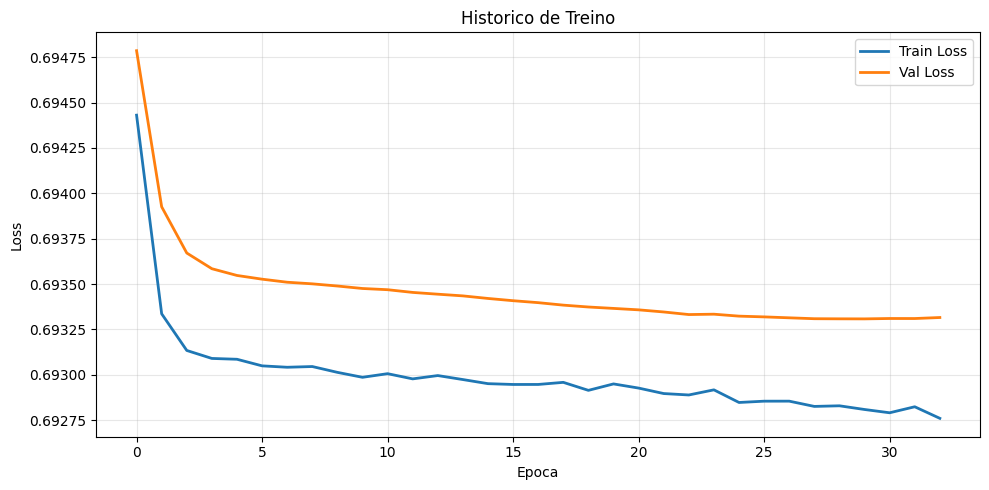

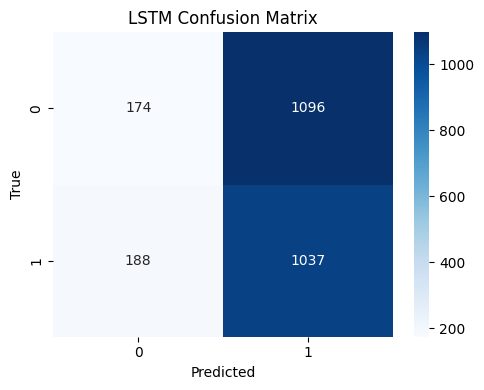

In [308]:
eval_results = evaluate_model(model, test_loader, device, threshold=0.5)
print("LSTM")
print(f"    F1-Score: {eval_results['f1']:.4f}")
print(f"    Recall: {eval_results['recall']:.4f}")
print(f"    Precision: {eval_results['precision']:.4f}")


plot_training_history(history)
plot_confusion_matrix(eval_results, title="LSTM Confusion Matrix")

## MLP para Comparação


MLP Baseline
    F1-Score: 0.9918
    Recall: 0.9902
    Precision: 0.9935


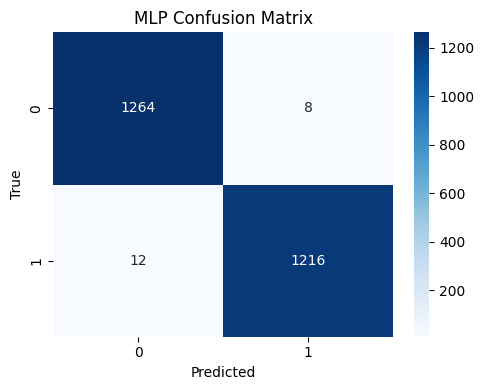

In [309]:


mlp_model = train_mlp_baseline(X_train_flat, y_train_flat, random_state=42)
mlp_results = evaluate_mlp_baseline(mlp_model, X_test_flat, y_test_flat)
print("\nMLP Baseline")
print(f"    F1-Score: {mlp_results['f1']:.4f}")
print(f"    Recall: {mlp_results['recall']:.4f}")
print(f"    Precision: {mlp_results['precision']:.4f}")
plot_confusion_matrix(mlp_results, title="MLP Confusion Matrix")


## Sobre os Resultados

O LSTM teve um desempenho ruim, ainda mais considerando que se trata de um toydataset. Porém isso deve à natureza do problema estruturado pelo make_circles(), onde não existe nenhum padrão temporal ou sequencial entre os dados, o que torna o LSTM não adequado para a tarefa pois ele não agrega em nada, somente adiciona ruído para a camada densa que fica após a unidade que contém os gates. Para efeito de comparação, também foi feito um teste com um MLP simples e ele desempenhou muito melhor em todas as métricas.